# Air Quality Prediction in Istanbul  
## Project 1: Problem Formulation & Exploratory Data Analysis (EDA)

**Course:** Introduction to Machine Learning YZM2001

**Student:** Berina Juković 

**Date:** April 2026  

---

### Problem Overview
This project aims to analyze air quality and weather data in Istanbul and predict whether air conditions are unhealthy based on pollution and environmental factors.

### GitHub Repository

You can find the full project repository here:  
https://github.com/bjukovic/Istanbul-Air-Quality-YZM2011-Project-Spring2026

## 1. Problem Statement

**Air pollution** is a major public health issue in large urban areas like Istanbul. Pollutants like **PM2.5**, **PM10**, and **nitrogen dioxide** can significantly affect respiratory and cardiovascular health, especially for vulnerable populations like *children, the elderly, and those with pre-existing health conditions*. Being able to predict and identify unhealthy air conditions can help individuals and authorities take preventive measures.

The goal of this project is to **predict if a given day in Istanbul has unhealthy air quality** using air pollution indicators and weather-related variables such as temperature, humidity, wind speed, and pressure. By combining these data sources, the project aims to identify patterns associated with poor air quality.

Weather variables are used as an explaination to capture environmental conditions that influence the formation, dispersion, and accumulation of air pollutants.

The prediction target is a binary variable called `unhealthy_air`, created from the `european_aqi` column. Observations with European AQI values greater than 50 are labeled as *unhealthy*, while the rest are labeled as *not unhealthy*.

This is a **classification** problem because the target variable consists of two categories: *unhealthy* and *not unhealthy*.

## 2. Dataset Description

This project uses a dataset created by merging two distinct, publicly available data sources focused on Istanbul's atmospheric conditions.

The **first dataset** is a weather dataset containing historical daily observations for Istanbul. It includes variables such as temperature, rainfall, sunrise and sunset times, wind speed, humidity, and atmospheric pressure. The data was originally collected from the World Weather Online service. It was obtained from Kaggle:
[Weather Dataset](https://www.kaggle.com/datasets/vonline9/weather-istanbul-data-20092019/data)

The **second dataset** is an air quality dataset containing historical time series data for Istanbul from 2013 to 2026. It includes key air pollution indicators such as PM10, PM2.5, carbon monoxide, nitrogen dioxide, sulphur dioxide, ozone, and air quality indices such as US AQI and European AQI. The air quality values were retrieved from the Open-Meteo Air Quality service (CAMS Europe domain), and city metadata is derived from the GeoNames database. This project uses only the `air_quality_historical.csv` file from the dataset. It was obtained from Kaggle:
[Air Quality Dataset](https://www.kaggle.com/datasets/nitirajkulkarni/istanbul-tr-745044)

Both datasets were downloaded as **CSV files** and merged using a **common date field** to align weather conditions with air quality measurements for the same day.

Before cleaning, the merged dataset contains **2436 rows and 23 columns**, representing the overlapping daily records shared by the air quality and weather datasets.

**The dataset contains the following features:**

*Air quality features:*
- `date` (datetime): observation date of the air quality measurements  
- `pm10` (float): daily concentration of particulate matter (PM10)  
- `pm2_5` (float): daily concentration of fine particulate matter (PM2.5)  
- `carbon_monoxide` (float): daily carbon monoxide concentration  
- `nitrogen_dioxide` (float): daily nitrogen dioxide (NO₂) concentration  
- `sulphur_dioxide` (float): daily sulphur dioxide (SO₂) concentration  
- `ozone` (float): daily ozone concentration  
- `aerosol_optical_depth` (float): measure of aerosol concentration in the atmosphere  
- `dust` (float): atmospheric dust concentration  
- `uv_index` (float): ultraviolet radiation index  
- `us_aqi` (float): air quality index based on US standards  
- `european_aqi` (float): air quality index based on European standards  

*Weather features:*
- `Condition` (categorical): general weather condition (e.g., sunny, cloudy)  
- `Rain` (float): daily rainfall amount  
- `MaxTemp` (integer): maximum daily temperature  
- `MinTemp` (integer): minimum daily temperature  
- `SunRise` (string/time): time of sunrise  
- `SunSet` (string/time): time of sunset  
- `MoonRise` (string/time): time of moonrise  
- `MoonSet` (string/time): time of moonset  
- `AvgWind` (integer): average daily wind speed  
- `AvgHumidity` (integer): average daily humidity  
- `AvgPressure` (integer): average daily atmospheric pressure  

*Target variable used later in the project:*
- `unhealthy_air` (binary): a derived target variable created later from `european_aqi`, where values greater than 50 are labeled as unhealthy

**Limitations and biases:**

- The two datasets cover different time ranges, and the weather dataset spans a shorter period than the air quality dataset. As a result, merging them reduces the usable data to the overlapping dates only.  
- Several features contain missing values. In particular, `aerosol_optical_depth` and `uv_index` are entirely missing in the overlapping period. Other variables such as `dust`, `carbon_monoxide`, and `sulphur_dioxide` also contain a significant number of missing observations, which must be addressed during data cleaning.  
- The datasets originate from different sources, which may introduce inconsistencies in measurement methods, units, or data collection processes.  
- Air quality index variables (`us_aqi` and `european_aqi`) are derived summary measures rather than direct pollutant readings. In this project, `european_aqi` is used to construct the target variable, so it is not used as an input feature to avoid data leakage.  
- The dataset represents aggregated daily observations and may not capture short-term fluctuations in air quality within a single day.

## 3. Data Loading & Initial Inspection

In [1]:
import pandas as pd

# Load datasets
weather_df = pd.read_csv("weather.csv")
air_df = pd.read_csv("air_quality_historical.csv")

# Convert date columns
weather_df['DateTime'] = pd.to_datetime(weather_df['DateTime'], dayfirst=True)
air_df['date'] = pd.to_datetime(air_df['date'])

# Rename to match
weather_df = weather_df.rename(columns={'DateTime': 'date'})

# Merge datasets
df = pd.merge(air_df, weather_df, on='date', how='inner')

In [2]:
df.head()

,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,...,Rain,MaxTemp,MinTemp,SunRise,SunSet,MoonRise,MoonSet,AvgWind,AvgHumidity,AvgPressure
0,2013-01-01,32.690476,18.980952,NaN,25.442857,NaN,24.666667,NaN,NaN,NaN,...,0.08,9,7,08:29:00,17:47:00,22:0:00,10:29:00,17,84,1022
1,2013-01-02,90.816667,68.870833,NaN,57.741667,NaN,11.791667,NaN,NaN,NaN,...,0.00,10,8,08:29:00,17:48:00,23:2:00,10:59:00,4,78,1024
2,2013-01-03,85.120833,68.258333,NaN,54.129167,NaN,8.041667,NaN,NaN,NaN,...,0.00,10,8,08:29:00,17:49:00,NaN,11:28:00,8,82,1028
3,2013-01-04,58.016667,47.866667,NaN,33.491667,NaN,27.625000,NaN,NaN,NaN,...,0.45,9,7,08:29:00,17:49:00,12:6:00,11:58:00,14,77,1021
4,2013-01-05,37.275000,34.100000,NaN,36.583333,NaN,21.000000,NaN,NaN,NaN,...,3.26,8,7,08:29:00,17:50:00,1:11:00,0:29:00,12,72,1013


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2436 entries, 0 to 2435
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   2436 non-null   datetime64[ns]
 1   pm10                   2436 non-null   float64       
 2   pm2_5                  2436 non-null   float64       
 3   carbon_monoxide        1341 non-null   float64       
 4   nitrogen_dioxide       2436 non-null   float64       
 5   sulphur_dioxide        1341 non-null   float64       
 6   ozone                  2436 non-null   float64       
 7   aerosol_optical_depth  0 non-null      float64       
 8   dust                   610 non-null    float64       
 9   uv_index               0 non-null      float64       
 10  us_aqi                 2435 non-null   float64       
 11  european_aqi           2435 non-null   float64       
 12  Condition              2436 non-null   object        
 13  Rai

In [4]:
df.describe(include='all')

,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,...,Rain,MaxTemp,MinTemp,SunRise,SunSet,MoonRise,MoonSet,AvgWind,AvgHumidity,AvgPressure
count,2436,2436.000000,2436.000000,1341.000000,2436.000000,1341.000000,2436.000000,0.0,610.000000,0.0,...,2436.000000,2436.000000,2436.00000,2436,2436,2353,2355,2436.000000,2436.000000,2436.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,178,185,1177,1173,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,05:32:00,20:40:00,11:49:00,5:40:00,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,103,101,9,7,NaN,NaN,NaN
mean,2016-05-02 12:00:00,32.789148,23.583036,261.219492,33.228633,7.629375,43.452603,NaN,2.071311,NaN,...,0.935238,18.252463,14.21798,NaN,NaN,NaN,NaN,17.419540,70.178571,1015.495484
min,2013-01-01 00:00:00,7.183333,4.354167,120.333333,8.450000,1.791667,2.291667,NaN,0.000000,NaN,...,0.000000,-1.000000,-5.00000,NaN,NaN,NaN,NaN,2.000000,40.000000,995.000000
25%,2014-09-01 18:00:00,21.639583,14.507292,200.958333,21.468750,4.437500,30.239583,NaN,0.000000,NaN,...,0.000000,12.000000,9.00000,NaN,NaN,NaN,NaN,11.000000,64.000000,1011.000000
50%,2016-05-02 12:00:00,29.145833,20.125000,243.166667,30.195833,6.316667,43.541667,NaN,0.500000,NaN,...,0.020000,18.000000,14.00000,NaN,NaN,NaN,NaN,17.000000,70.000000,1015.000000
75%,2018-01-01 06:00:00,39.854167,29.878125,306.208333,42.567708,9.495833,56.281250,NaN,2.197917,NaN,...,0.680000,25.000000,21.00000,NaN,NaN,NaN,NaN,22.000000,77.000000,1019.000000
max,2019-09-02 00:00:00,262.483333,96.158333,660.250000,113.808333,42.304167,92.583333,NaN,47.125000,NaN,...,42.000000,35.000000,26.00000,NaN,NaN,NaN,NaN,56.000000,94.000000,1038.000000


In [5]:
df.shape

(2436, 23)

- The datasets were loaded using the pandas library and merged based on a common date column. The `DateTime` column in the weather dataset was converted to a datetime format using day-first parsing to ensure compatibility with the air quality dataset.

- The `DateTime` column was then renamed to `date` so that both datasets shared a consistent datetime column, allowing for a clean merge without duplicating date-related features.

- An inner join was used during merging to retain only the overlapping dates between the two datasets, ensuring that each row contains both weather and air quality information for the same day.

- The `head()` function provides an overview of the first few rows of the merged dataset, showing the structure and sample values of both air quality and weather-related features.

- The `info()` function reveals the structure of the dataset, including data types and missing values. Several variables contain missing values, with some columns such as `aerosol_optical_depth` and `uv_index` having no recorded data.

- The dataset contains multiple data types, including `float64` (for pollutant concentrations), `int64` (for weather measurements such as temperature and humidity), `object` (for categorical and time-based features such as `Condition`, `SunRise`, and `SunSet`), and `datetime64` (for the `date` column).

- The `describe(include='all')` function summarizes both numerical and categorical features. For example, PM2.5 values range from approximately 4 to 96, while the European AQI ranges from around 14 to 148, indicating variability in air quality levels across the dataset. Weather variables such as temperature, humidity, and pressure also show realistic variation over time.

- Before data cleaning, the merged dataset contains **2436 rows and 23 columns**.

## 4. Data Cleaning

### Missing Values

In [6]:
df.isnull().sum()

date                        0
pm10                        0
pm2_5                       0
carbon_monoxide          1095
nitrogen_dioxide            0
sulphur_dioxide          1095
ozone                       0
aerosol_optical_depth    2436
dust                     1826
uv_index                 2436
us_aqi                      1
european_aqi                1
Condition                   0
Rain                        0
MaxTemp                     0
MinTemp                     0
SunRise                     0
SunSet                      0
MoonRise                   83
MoonSet                    81
AvgWind                     0
AvgHumidity                 0
AvgPressure                 0
dtype: int64

The dataset was checked for missing values using `isnull().sum()`. Several features contained missing values.

- The columns `aerosol_optical_depth` and `uv_index` contained no valid observations (all values were missing), so they were removed from the dataset.
- The columns `carbon_monoxide`, `sulphur_dioxide`, and `dust` contained a significant number of missing values but still retained useful information. These were imputed using the median value of each column to reduce the impact of extreme values.
- Other columns contained little to no missing data and were left unchanged.

In [7]:
# Drop columns with all missing values
df = df.drop(columns=['aerosol_optical_depth', 'uv_index'])

# Impute missing values
df['carbon_monoxide'] = df['carbon_monoxide'].fillna(df['carbon_monoxide'].median())
df['sulphur_dioxide'] = df['sulphur_dioxide'].fillna(df['sulphur_dioxide'].median())
df['dust'] = df['dust'].fillna(df['dust'].median())

### Duplicate Rows

In [8]:
df.duplicated().sum()

np.int64(0)

The dataset was checked for duplicate rows using `duplicated()`. No duplicate rows were found, so no records were removed.

### Data Types

In [9]:
df.dtypes

date                datetime64[ns]
pm10                       float64
pm2_5                      float64
carbon_monoxide            float64
nitrogen_dioxide           float64
sulphur_dioxide            float64
ozone                      float64
dust                       float64
us_aqi                     float64
european_aqi               float64
Condition                   object
Rain                       float64
MaxTemp                      int64
MinTemp                      int64
SunRise                     object
SunSet                      object
MoonRise                    object
MoonSet                     object
AvgWind                      int64
AvgHumidity                  int64
AvgPressure                  int64
dtype: object

The data types of each column were examined using `df.dtypes`. The `date` column is stored as a datetime object, which is appropriate for time-based analysis. Numerical variables are correctly stored as integers or floats, and categorical variables such as `Condition` are stored as object types.

The columns `SunRise`, `SunSet`, `MoonRise`, and `MoonSet` are stored as object types representing time values. Although these could be converted into a datetime or time format, no transformation was applied. These columns were not converted since they are not directly used in the current exploratory analysis. However, they may be transformed into time-based features in later stages of the project if needed.

No major inconsistencies in data types were found, so no further conversions were required.

### Outliers

In [10]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_summary.append({
        'feature': col,
        'lower_bound': round(lower_bound, 3),
        'upper_bound': round(upper_bound, 3),
        'outlier_count': int(outlier_count)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,feature,lower_bound,upper_bound,outlier_count
0,pm10,-5.682,67.176,93
1,pm2_5,-8.549,52.934,72
2,carbon_monoxide,211.010,276.677,879
3,nitrogen_dioxide,-10.180,74.216,39
4,sulphur_dioxide,4.930,7.789,907
5,ozone,-8.823,95.344,0
6,dust,0.500,0.500,606
7,us_aqi,9.062,135.062,92
8,european_aqi,-16.260,110.656,2
9,Rain,-1.020,1.700,358


Outliers were examined using the Interquartile Range (IQR) method across all numerical features. For each variable, values below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR` were flagged as potential outliers.

The results show that several pollution and weather variables contain extreme observations. These values are likely to reflect genuine environmental conditions, such as high-pollution days or unusual weather patterns, rather than clear data-entry errors.

Therefore, no outliers were removed or capped at this stage, and all observations were retained.

### Inconsistent categories

In [11]:
df['Condition'] = df['Condition'].str.strip()
df['Condition'].value_counts()

Condition
Sunny                                  1357
Partly cloudy                           488
Overcast                                283
Cloudy                                  173
Patchy rain possible                     50
Thundery outbreaks possible              20
Light rain shower                        17
Light rain                               10
Moderate or heavy rain shower             5
Light drizzle                             5
Moderate rain                             4
Light sleet                               3
Blizzard                                  3
Patchy light rain with thunder            3
Moderate or heavy rain with thunder       3
Heavy rain                                3
Light sleet showers                       1
Moderate snow                             1
Mist                                      1
Moderate or heavy sleet                   1
Moderate or heavy snow showers            1
Patchy light drizzle                      1
Moderate rain at times

The dataset contains one main categorical feature, so category consistency was checked on that column. The `Condition` column was analyzed using `value_counts()` to identify potential inconsistencies in categorical labels.

No inconsistencies such as duplicate labels caused by capitalization or formatting differences were observed. Leading and trailing whitespace was removed as a precaution. While some categories occur infrequently, they represent valid weather conditions and were retained.

No further standardization was required.

### Target Variable Creation

In [12]:
df['unhealthy_air'] = (df['european_aqi'] > 50).astype(int)

A new binary target variable `unhealthy_air` was created using the `european_aqi` column. Values greater than 50 were labeled as unhealthy (1), while the remaining values were labeled as not unhealthy (0).

## 5. Univariate Analysis

In this section, each feature is analyzed individually.

- For **numerical features**, histograms are used to visualize the distribution, and the mean, median, standard deviation, and skewness are reported.
- For **categorical features**, bar charts are used to show category frequencies, and the most common categories are listed.
- For the **target variable**, extra detail is provided, including its distribution shape, range, and class balance if the task is classification.

### Numerical Features
For each numerical feature, we examine:
- Distribution using a histogram
- Mean
- Median
- Standard deviation
- Skewness


Feature: pm10
Mean: 32.79
Median: 29.15
Standard Deviation: 16.34
Skewness: 2.39


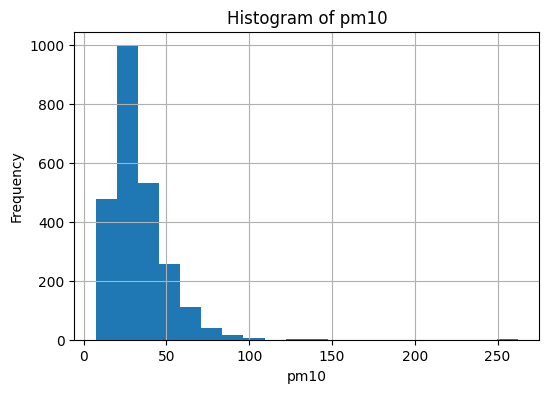


Feature: pm2_5
Mean: 23.58
Median: 20.12
Standard Deviation: 12.43
Skewness: 1.36


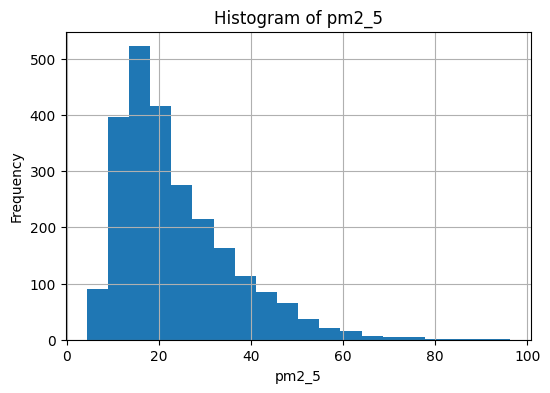


Feature: carbon_monoxide
Mean: 253.10
Median: 243.17
Standard Deviation: 58.61
Skewness: 1.67


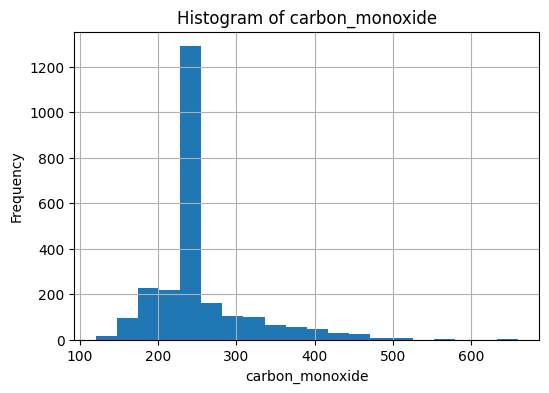


Feature: nitrogen_dioxide
Mean: 33.23
Median: 30.20
Standard Deviation: 15.18
Skewness: 0.95


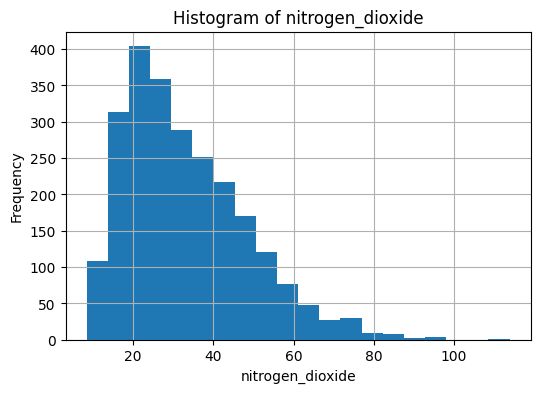


Feature: sulphur_dioxide
Mean: 7.04
Median: 6.32
Standard Deviation: 3.54
Skewness: 3.30


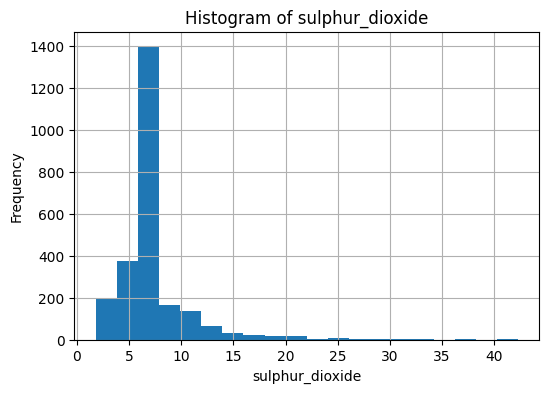


Feature: ozone
Mean: 43.45
Median: 43.54
Standard Deviation: 17.67
Skewness: 0.04


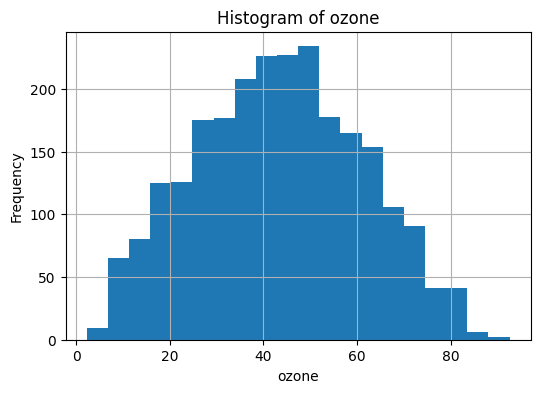


Feature: dust
Mean: 0.89
Median: 0.50
Standard Deviation: 2.31
Skewness: 10.52


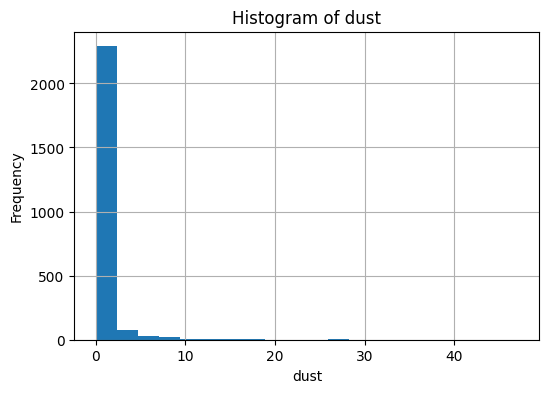


Feature: us_aqi
Mean: 74.25
Median: 67.79
Standard Deviation: 26.04
Skewness: 1.03


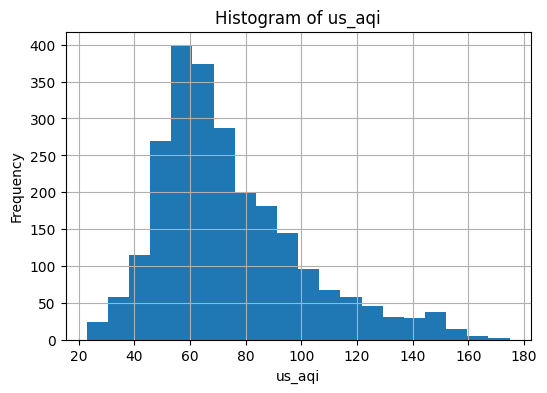


Feature: european_aqi
Mean: 47.07
Median: 43.38
Standard Deviation: 18.45
Skewness: 0.48


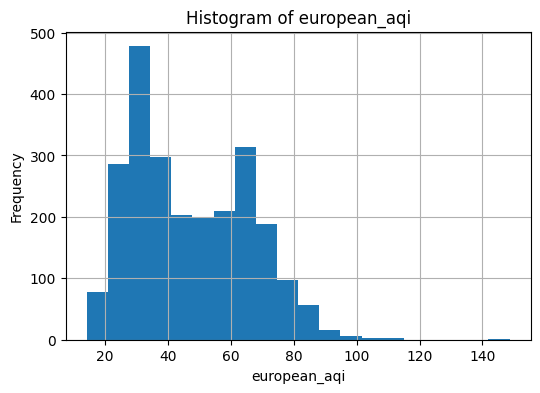


Feature: Rain
Mean: 0.94
Median: 0.02
Standard Deviation: 2.63
Skewness: 6.51


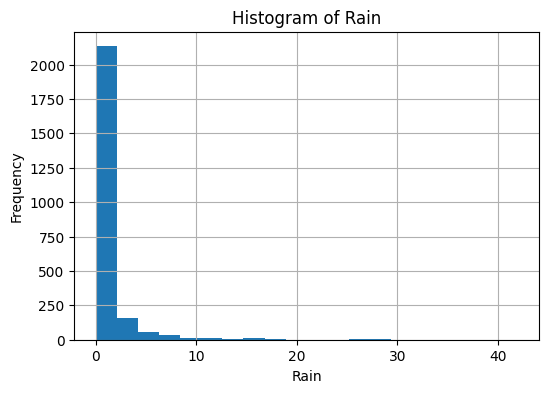


Feature: MaxTemp
Mean: 18.25
Median: 18.00
Standard Deviation: 7.43
Skewness: -0.07


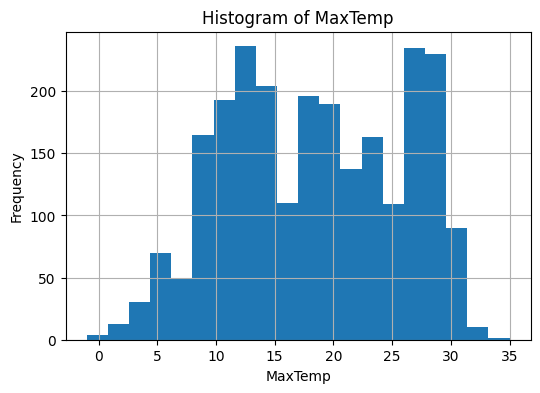


Feature: MinTemp
Mean: 14.22
Median: 14.00
Standard Deviation: 6.70
Skewness: -0.07


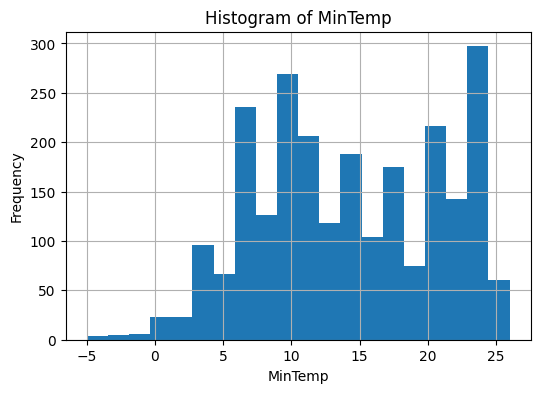


Feature: AvgWind
Mean: 17.42
Median: 17.00
Standard Deviation: 7.91
Skewness: 0.72


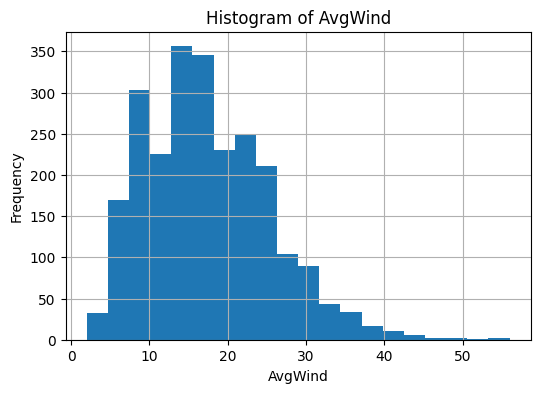


Feature: AvgHumidity
Mean: 70.18
Median: 70.00
Standard Deviation: 8.97
Skewness: -0.09


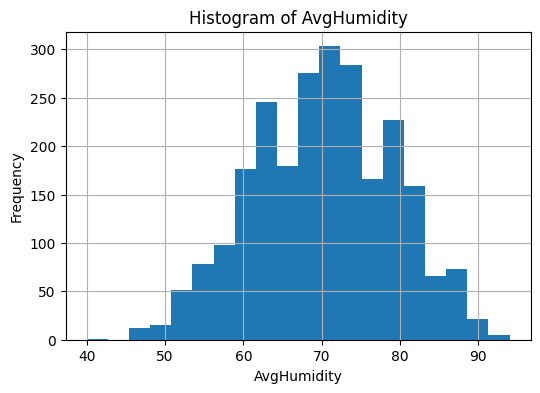


Feature: AvgPressure
Mean: 1015.50
Median: 1015.00
Standard Deviation: 6.28
Skewness: 0.34


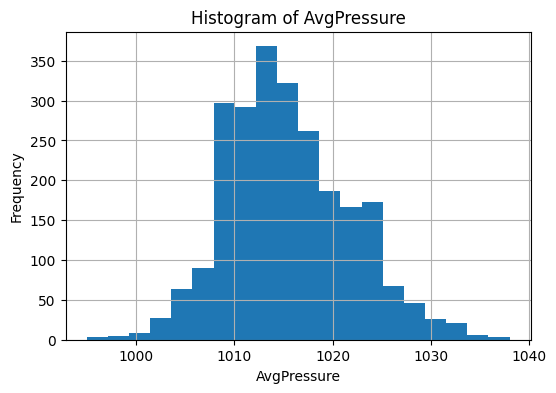


Feature: unhealthy_air
Mean: 0.42
Median: 0.00
Standard Deviation: 0.49
Skewness: 0.32


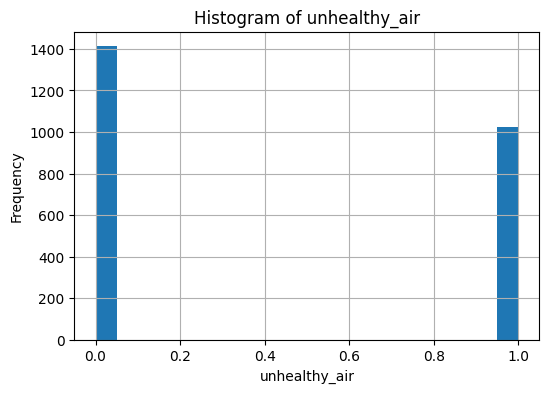

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    print(f"\nFeature: {col}")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Standard Deviation: {df[col].std():.2f}")
    print(f"Skewness: {df[col].skew():.2f}")
    
    plt.figure(figsize=(6,4))
    df[col].dropna().hist(bins=20)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

### Categorical Features
For each categorical feature, we examine:
- Distribution using a bar chart
- Most frequent categories
- Frequency of top categories


Feature: Condition
Condition
Sunny                            1357
Partly cloudy                     488
Overcast                          283
Cloudy                            173
Patchy rain possible               50
Thundery outbreaks possible        20
Light rain shower                  17
Light rain                         10
Moderate or heavy rain shower       5
Light drizzle                       5
Name: count, dtype: int64


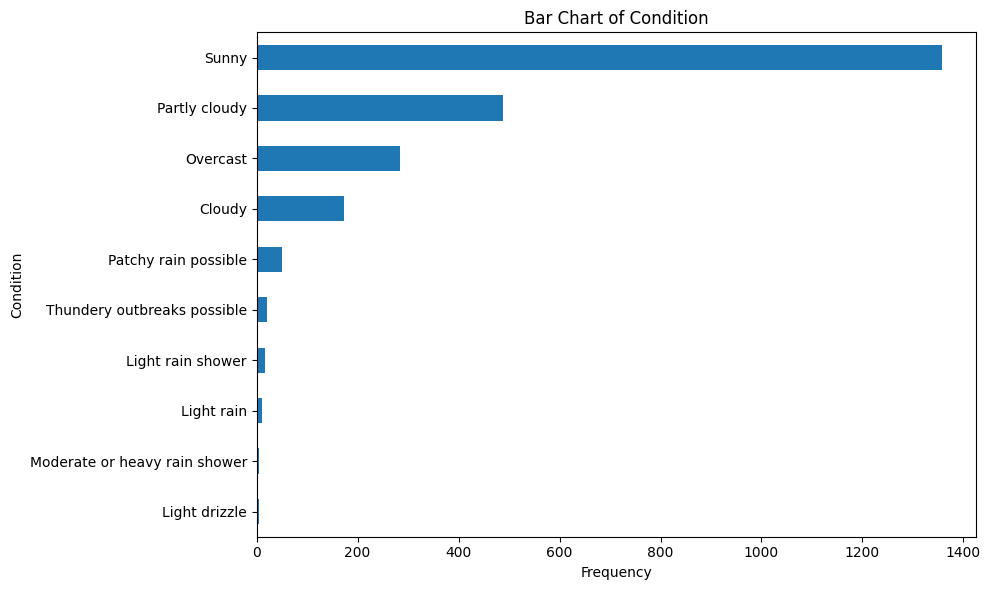


Feature: SunRise
SunRise
05:32:00    103
08:29:00     76
05:33:00     47
08:28:00     47
05:34:00     37
08:27:00     33
05:35:00     32
08:26:00     27
05:36:00     26
05:37:00     25
Name: count, dtype: int64


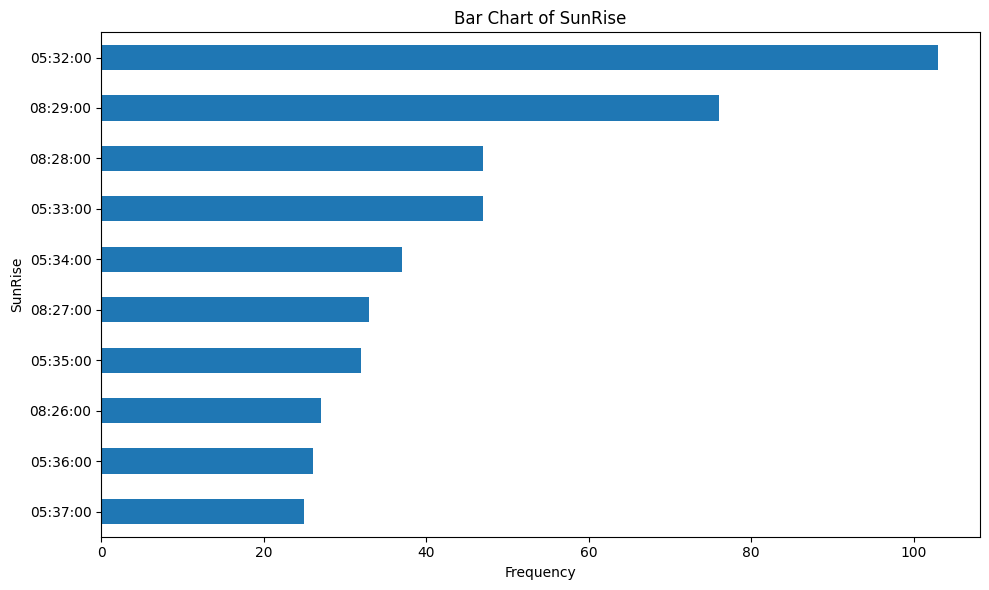


Feature: SunSet
SunSet
20:40:00    101
17:36:00     66
20:39:00     46
17:37:00     43
20:38:00     35
20:37:00     32
17:38:00     30
20:36:00     26
17:39:00     25
20:35:00     24
Name: count, dtype: int64


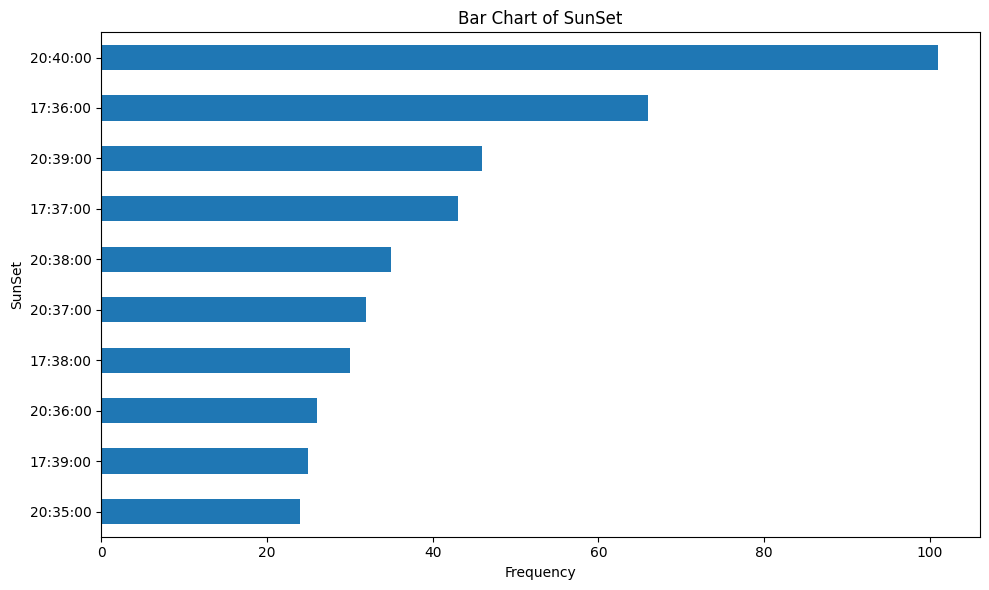


Feature: MoonRise
MoonRise
11:49:00    9
23:12:00    7
14:0:00     7
4:15:00     7
2:26:00     6
14:59:00    6
17:31:00    6
3:27:00     6
8:17:00     6
12:35:00    5
Name: count, dtype: int64


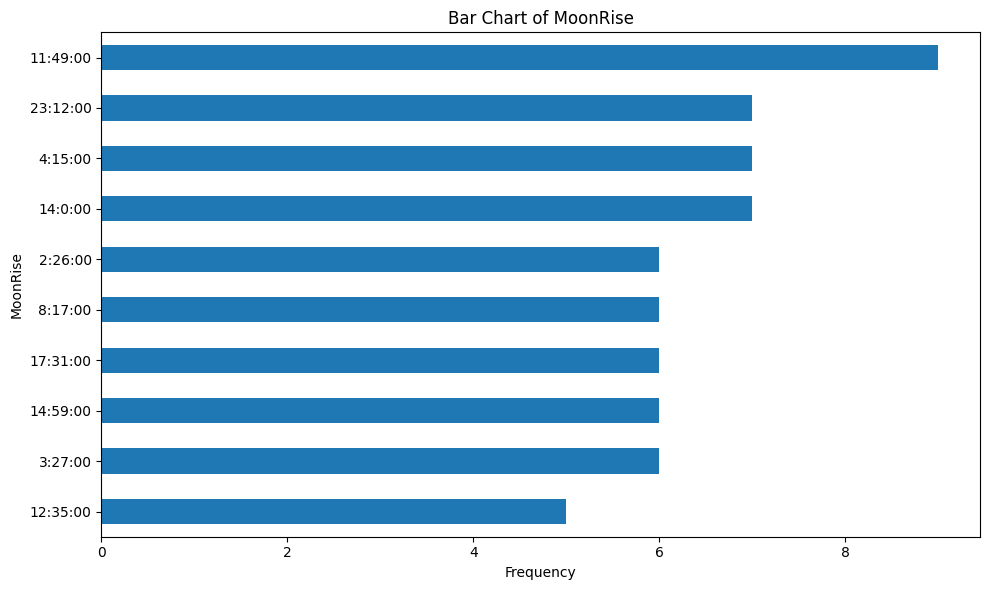


Feature: MoonSet
MoonSet
5:40:00     7
23:10:00    7
6:21:00     7
18:28:00    7
9:18:00     6
1:22:00     6
4:36:00     6
2:37:00     6
22:46:00    6
10:16:00    6
Name: count, dtype: int64


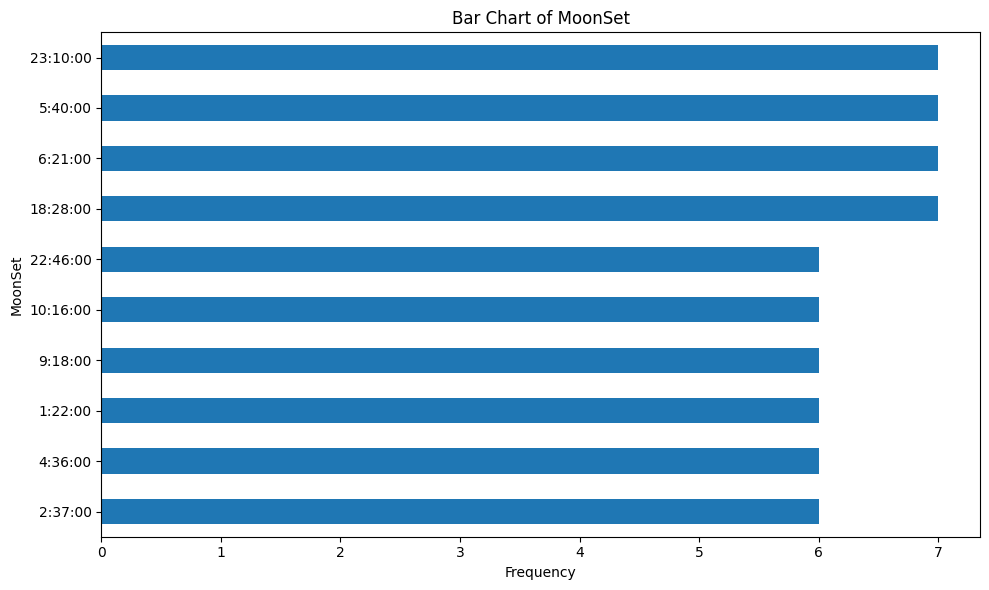

In [14]:
# Select categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"\nFeature: {col}")
    print(df[col].value_counts().head(10))
    
    plt.figure(figsize=(10,6))
    df[col].value_counts().head(10).sort_values().plot(kind='barh')
    plt.title(f'Bar Chart of {col}')
    plt.xlabel('Frequency')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### Target Variable Analysis
The target variable is analyzed in more detail. We examine:
- Distribution shape
- Range
- Class balance, if this is a classification problem

Target variable: unhealthy_air
Range: 0 to 1

Class counts:
unhealthy_air
0    1413
1    1023
Name: count, dtype: int64

Class proportions:
unhealthy_air
0    0.58
1    0.42
Name: proportion, dtype: float64


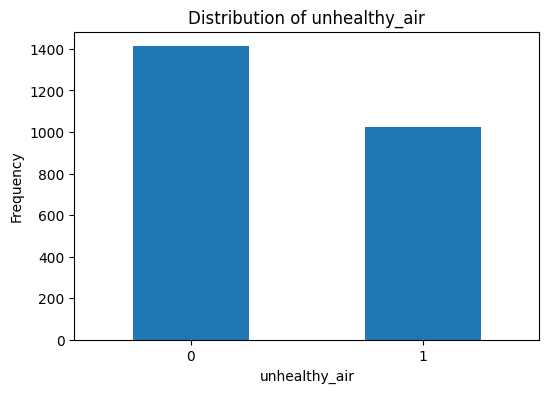

In [15]:
import matplotlib.pyplot as plt

if 'unhealthy_air' not in df.columns:
    df['unhealthy_air'] = (df['european_aqi'] > 50).astype(int)

print('Target variable: unhealthy_air')
print('Range:', df['unhealthy_air'].min(), 'to', df['unhealthy_air'].max())
print('\nClass counts:')
print(df['unhealthy_air'].value_counts().sort_index())
print('\nClass proportions:')
print(df['unhealthy_air'].value_counts(normalize=True).sort_index().round(3))

plt.figure(figsize=(6,4))
df['unhealthy_air'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of unhealthy_air')
plt.xlabel('unhealthy_air')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

The target variable `unhealthy_air` is binary, so its values range from 0 to 1. The class counts and class proportions were examined to assess class balance.

This allows us to see whether the classification target is reasonably balanced or whether one class appears much more frequently than the other.

## 6. Bivariate & Multivariate Analysis 

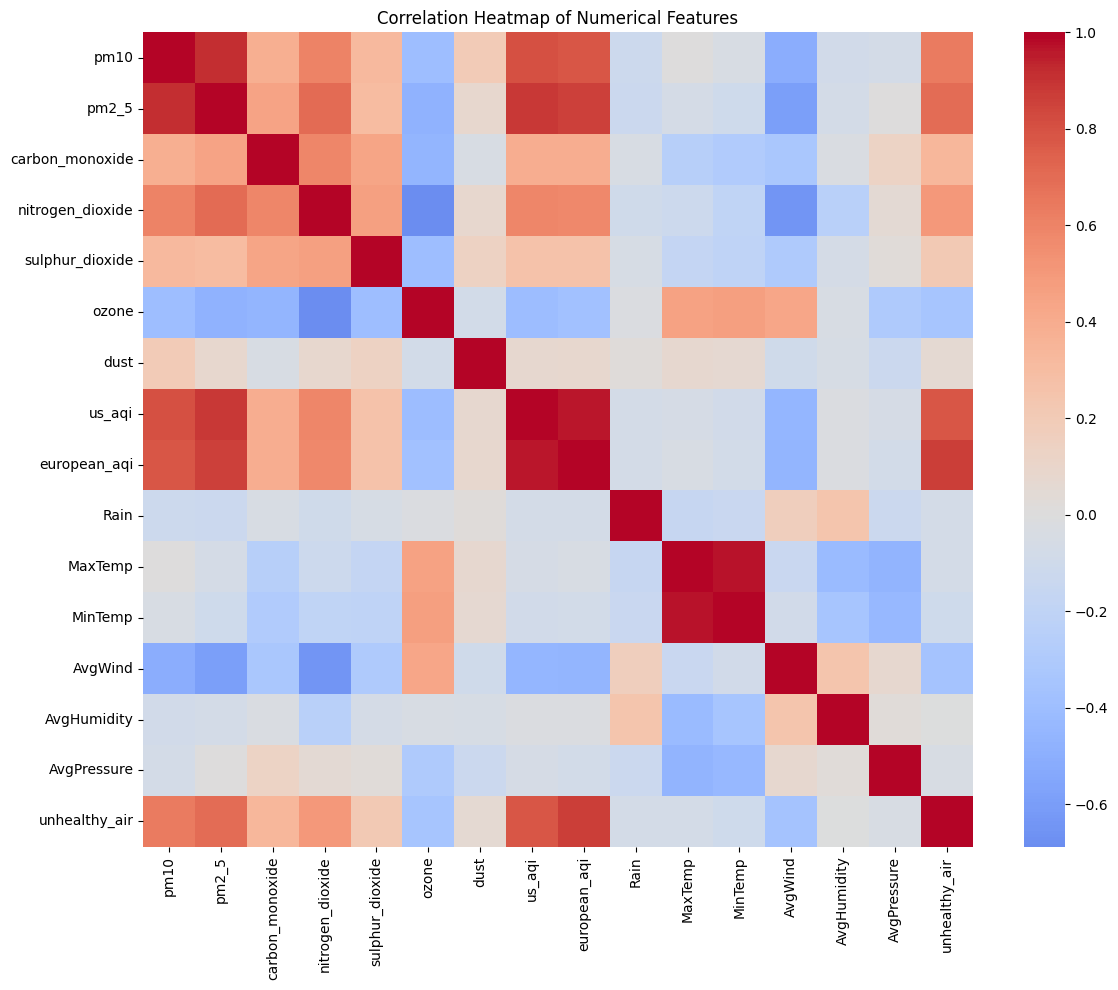

unhealthy_air       1.000000
european_aqi        0.873243
us_aqi              0.783696
pm2_5               0.695701
pm10                0.632855
nitrogen_dioxide    0.500365
carbon_monoxide     0.338150
sulphur_dioxide     0.212445
dust                0.061482
AvgHumidity        -0.006555
AvgPressure        -0.047789
Rain               -0.070470
MaxTemp            -0.073056
MinTemp            -0.105062
ozone              -0.340201
AvgWind            -0.365035
Name: unhealthy_air, dtype: float64

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

if 'unhealthy_air' not in df.columns:
    df['unhealthy_air'] = (df['european_aqi'] > 50).astype(int)

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

corr_with_target = corr_matrix['unhealthy_air'].sort_values(ascending=False)
corr_with_target

In [17]:
candidate_features = corr_with_target.drop(labels=['unhealthy_air', 'european_aqi', 'us_aqi'], errors='ignore')
top_features = candidate_features.abs().sort_values(ascending=False).head(4).index
top_features

Index(['pm2_5', 'pm10', 'nitrogen_dioxide', 'AvgWind'], dtype='object')

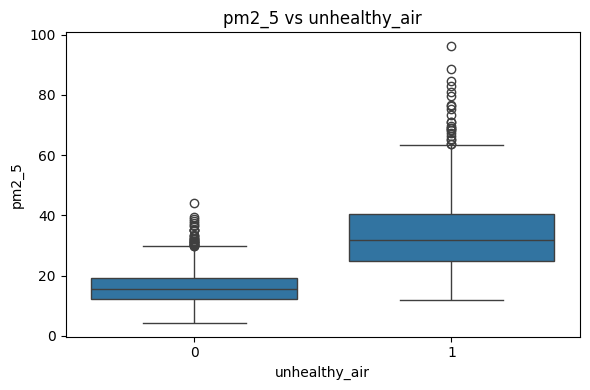

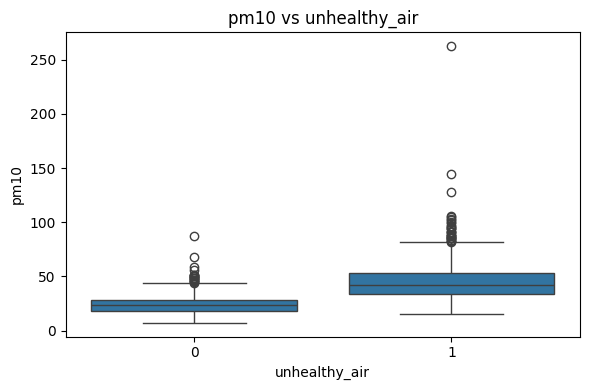

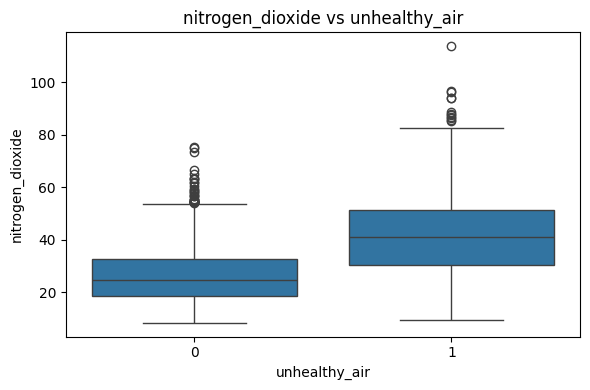

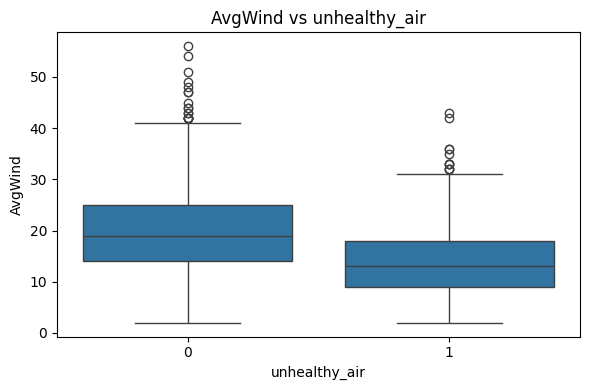

In [18]:
for col in top_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='unhealthy_air', y=col, data=df)
    plt.title(f'{col} vs unhealthy_air')
    plt.xlabel('unhealthy_air')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

The correlation heatmap illustrates the relationships between all numerical variables in the dataset. Strong positive correlations are observed between air quality indices (`european_aqi`, `us_aqi`) and pollutant concentrations such as `pm2_5`, `pm10`, and `nitrogen_dioxide`. This is expected, as AQI values are directly derived from pollutant levels.

Focusing on the target variable `unhealthy_air`, the strongest positive correlations (excluding AQI itself) are:

- `pm2_5` (0.696)  
- `pm10` (0.633)  
- `nitrogen_dioxide` (0.500)  

These results indicate that particulate matter and nitrogen dioxide are the most influential factors in determining whether air quality is unhealthy.

The box plots of the top features (`pm2_5`, `pm10`, `nitrogen_dioxide`, and `AvgWind`) further support this observation. For pollutant variables, unhealthy days show higher median values and wider distributions compared to healthy days, suggesting strong predictive power.

A notable and interesting observation is the negative correlation of `AvgWind` (-0.365) with `unhealthy_air`. This suggests that higher wind speeds are associated with better air quality, likely because wind helps disperse pollutants. Similarly, variables such as temperature and rainfall show weak or slightly negative correlations, indicating that weather affects air quality indirectly rather than being a primary driver.

Overall, pollutant-related variables are the strongest predictors of unhealthy air conditions, while weather-related variables play a secondary, moderating role. These findings will help guide feature selection in the regression model in Project 2.

## 7. Key Findings & Next Steps

### Key Findings

1. Pollution-related variables are the strongest drivers of air quality. In particular, `pm2_5`, `pm10`, and `nitrogen_dioxide` show the highest positive correlations with `unhealthy_air`, indicating they are the main contributors to poor air conditions.

2. The box plot analysis reveals clear separation between unhealthy and non-unhealthy days for key pollutant variables, confirming that these features have strong predictive potential.

3. Weather variables generally have weak relationships with the target. However, `AvgWind` shows a moderate negative correlation, suggesting that higher wind speeds help reduce pollution levels.

4. Several features contain outliers, especially pollutant variables. These were retained, as they likely represent real environmental extremes rather than errors.

5. Merging air quality and weather datasets reduced the dataset size due to non-overlapping time ranges, which may limit model performance.

### Most Predictive Features

The most predictive features are `pm2_5`, `pm10`, and `nitrogen_dioxide`, as they show the strongest correlations with `unhealthy_air` and clear separation between classes in the box plots. Among weather variables, `AvgWind` is the most informative, although its influence is weaker compared to pollutant variables.

### Remaining Data Quality Issues

- The dataset was reduced after merging due to different time coverage between sources.
- Some features required removal or imputation due to missing values (e.g., `aerosol_optical_depth`, `uv_index`, `carbon_monoxide`, `sulphur_dioxide`, `dust`).
- The target variable is derived from `european_aqi`, so AQI-related features must be excluded in future modeling to avoid data leakage.
- Time-related variables (`SunRise`, `SunSet`, `MoonRise`, `MoonSet`) remain unprocessed and may require feature engineering.

### Next Steps

The next step is to prepare the dataset for modeling in Project 2. Based on the EDA, pollutant variables will be used as primary predictors, while weather variables will be tested as additional features to evaluate their contribution to model performance.